In [1]:
from google.colab import files

uploaded = files.upload()

Saving IoT-Enabled Indoor Air Quality Monitoring Dataset.zip to IoT-Enabled Indoor Air Quality Monitoring Dataset.zip


In [2]:
import zipfile
import os

zip_file = "IoT-Enabled Indoor Air Quality Monitoring Dataset.zip"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("air_quality_data")

print("Dataset extracted successfully!")

print("\nFiles inside the extracted folder:")
for file in os.listdir("air_quality_data"):
    print(file)

Dataset extracted successfully!

Files inside the extracted folder:
IoT-Enabled Indoor Air Quality Monitoring Dataset


In [3]:
import os

folder = "air_quality_data/IoT-Enabled Indoor Air Quality Monitoring Dataset"

print("Files inside the dataset folder:")

for file in os.listdir(folder):
    print(file)

Files inside the dataset folder:
IAQ_ML.py.txt
air quality dataset.xlsx
IAQ_Raspberry pi.py.txt


In [4]:
import pandas as pd

file_path = "air_quality_data/IoT-Enabled Indoor Air Quality Monitoring Dataset/air quality dataset.xlsx"

df = pd.read_excel(file_path)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (1500, 12)


,Timestamp,Temperature (C),Humidity (%),Pressure (hPa),Gas Resistance (Ohms),PM2.5,TVOC (ppb),eCO2 (ppm),VOC Index,MQ135 Value,Voltage,PPM
0,2025-07-09 12:56:31,27.504023,41.587723,889.099607,52053,7,0,400,93,73,0.235484,0.473748
1,2025-07-09 12:56:37,27.503438,41.558374,889.098754,51990,8,0,403,94,72,0.232258,0.474672
2,2025-07-09 12:56:43,27.495430,41.580894,889.102470,52729,8,5,410,94,74,0.238710,0.474672
3,2025-07-09 12:56:49,27.497383,41.604544,889.096773,52827,8,4,403,94,73,0.235484,0.475549
4,2025-07-09 12:56:54,27.500898,41.587369,889.093350,51706,8,2,400,94,73,0.235484,0.475549


In [5]:
print("Column names:")
print(df.columns.tolist())

Column names:
['Timestamp', 'Temperature (C)', 'Humidity (%)', 'Pressure (hPa)', 'Gas Resistance (Ohms)', 'PM2.5', 'TVOC (ppb)', 'eCO2 (ppm)', 'VOC Index', 'MQ135 Value', 'Voltage', 'PPM']


In [6]:
print("Dataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nStatistical Summary:")
display(df.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Timestamp              1500 non-null   object 
 1   Temperature (C)        1500 non-null   float64
 2   Humidity (%)           1500 non-null   float64
 3   Pressure (hPa)         1500 non-null   float64
 4   Gas Resistance (Ohms)  1500 non-null   int64  
 5   PM2.5                  1500 non-null   int64  
 6   TVOC (ppb)             1500 non-null   int64  
 7   eCO2 (ppm)             1500 non-null   int64  
 8   VOC Index              1500 non-null   int64  
 9   MQ135 Value            1500 non-null   int64  
 10  Voltage                1500 non-null   float64
 11  PPM                    1500 non-null   float64
dtypes: float64(5), int64(6), object(1)
memory usage: 140.8+ KB
None

Missing Values:
Timestamp                0
Temperature (C)          0
Humi

,Temperature (C),Humidity (%),Pressure (hPa),Gas Resistance (Ohms),PM2.5,TVOC (ppb),eCO2 (ppm),VOC Index,MQ135 Value,Voltage,PPM
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,27.587570,40.695251,888.150824,53780.204667,6.231333,8.312000,403.519333,99.840667,80.689333,0.260288,0.365903
std,0.072361,0.411694,0.528725,1384.663547,1.133729,9.648941,5.465913,4.090448,4.153913,0.013400,0.058141
min,27.444063,40.106833,887.206387,42146.000000,3.000000,0.000000,400.000000,92.000000,70.000000,0.225806,0.297610
25%,27.533076,40.382291,887.823037,53255.000000,5.000000,0.000000,400.000000,96.000000,82.000000,0.264516,0.334220
50%,27.590352,40.563812,888.130167,53657.000000,6.000000,5.000000,400.000000,100.000000,83.000000,0.267742,0.337084
75%,27.632734,40.869636,888.567020,54168.000000,7.000000,13.000000,406.000000,103.000000,83.000000,0.267742,0.342139
max,27.811641,42.104284,889.102470,65222.000000,11.000000,46.000000,453.000000,112.000000,104.000000,0.335484,0.493160


In [7]:
print("Unique values in each column:\n")

for column in df.columns:
    print(f"{column}: {df[column].nunique()} unique values")

Unique values in each column:

Timestamp: 1500 unique values
Temperature (C): 704 unique values
Humidity (%): 1463 unique values
Pressure (hPa): 1485 unique values
Gas Resistance (Ohms): 171 unique values
PM2.5: 8 unique values
TVOC (ppb): 45 unique values
eCO2 (ppm): 25 unique values
VOC Index: 21 unique values
MQ135 Value: 18 unique values
Voltage: 18 unique values
PPM: 373 unique values


In [8]:
# Convert Timestamp to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Create useful time-based features
df['Hour'] = df['Timestamp'].dt.hour
df['Minute'] = df['Timestamp'].dt.minute
df['Day'] = df['Timestamp'].dt.day

# Drop the original timestamp
df = df.drop('Timestamp', axis=1)

# Separate features and target
X = df.drop('PPM', axis=1)
y = df['PPM']

print("Data preparation completed!")
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Data preparation completed!
Feature shape: (1500, 13)
Target shape: (1500,)

Features:
['Temperature (C)', 'Humidity (%)', 'Pressure (hPa)', 'Gas Resistance (Ohms)', 'PM2.5', 'TVOC (ppb)', 'eCO2 (ppm)', 'VOC Index', 'MQ135 Value', 'Voltage', 'Hour', 'Minute', 'Day']

Target:
PPM


In [9]:
print("First 5 rows of features:")
display(X.head())

print("\nFirst 5 target values:")
display(y.head())

First 5 rows of features:


,Temperature (C),Humidity (%),Pressure (hPa),Gas Resistance (Ohms),PM2.5,TVOC (ppb),eCO2 (ppm),VOC Index,MQ135 Value,Voltage,Hour,Minute,Day
0,27.504023,41.587723,889.099607,52053,7,0,400,93,73,0.235484,12,56,9
1,27.503438,41.558374,889.098754,51990,8,0,403,94,72,0.232258,12,56,9
2,27.495430,41.580894,889.102470,52729,8,5,410,94,74,0.238710,12,56,9
3,27.497383,41.604544,889.096773,52827,8,4,403,94,73,0.235484,12,56,9
4,27.500898,41.587369,889.093350,51706,8,2,400,94,73,0.235484,12,56,9



First 5 target values:


,PPM
0,0.473748
1,0.474672
2,0.474672
3,0.475549
4,0.475549


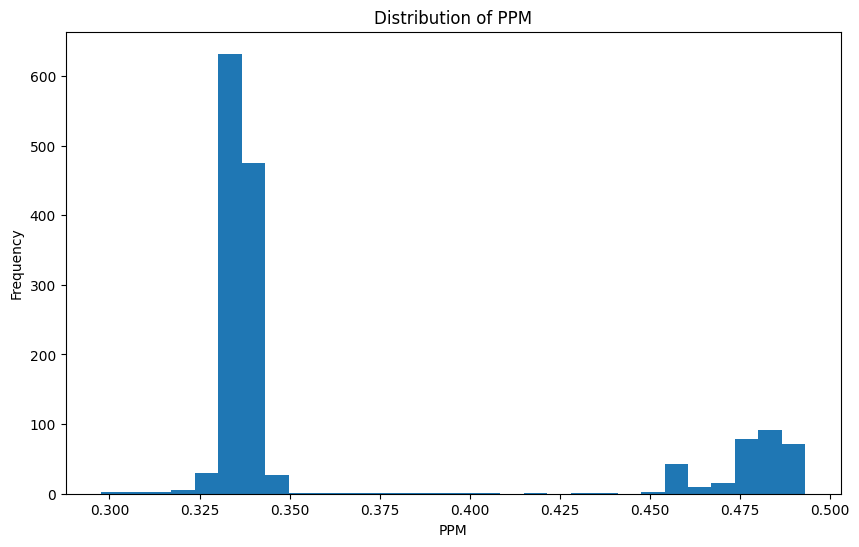

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(y, bins=30)
plt.xlabel("PPM")
plt.ylabel("Frequency")
plt.title("Distribution of PPM")
plt.show()

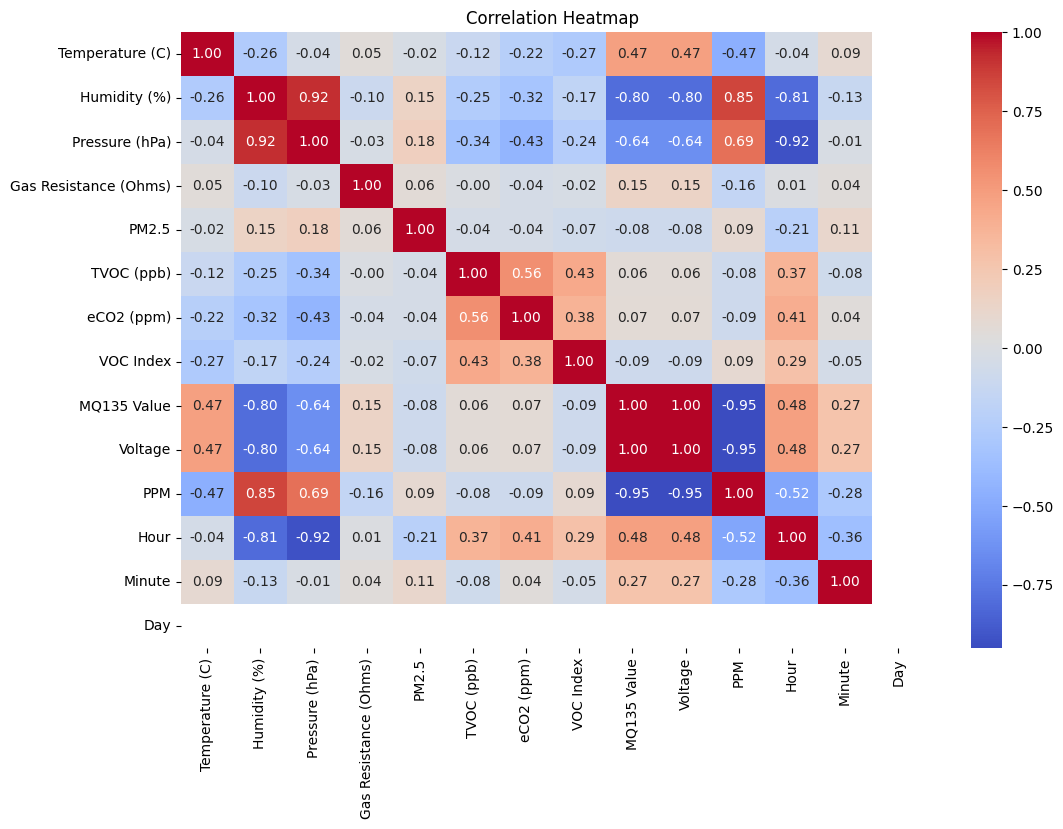

In [11]:
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

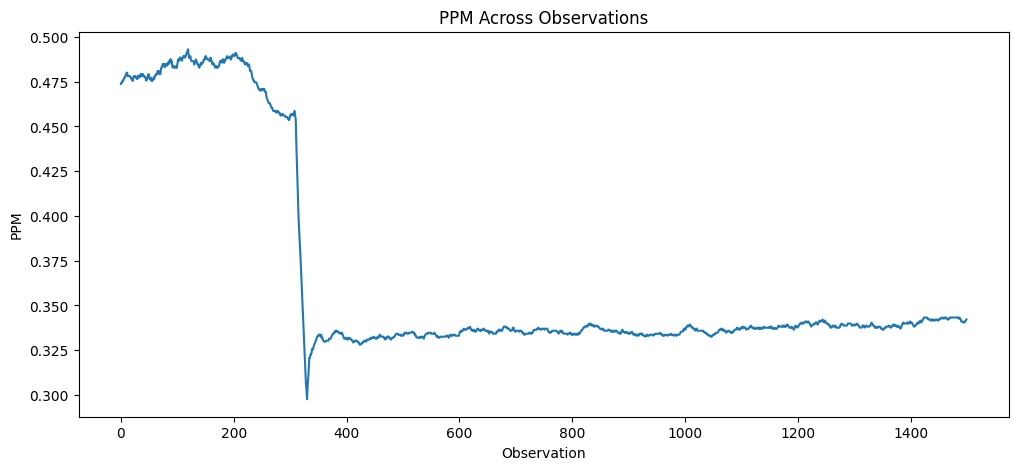

In [12]:
plt.figure(figsize=(12, 5))
plt.plot(y)
plt.xlabel("Observation")
plt.ylabel("PPM")
plt.title("PPM Across Observations")
plt.show()

In [13]:
from sklearn.model_selection import train_test_split

# Select features and target
X = df[
    [
        'Temperature (C)',
        'Humidity (%)',
        'Pressure (hPa)',
        'Gas Resistance (Ohms)',
        'PM2.5',
        'TVOC (ppb)',
        'eCO2 (ppm)',
        'VOC Index',
        'MQ135 Value',
        'Voltage',
        'Hour',
        'Minute',
        'Day'
    ]
]

y = df['PPM']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Data splitting completed!")
print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Data splitting completed!
Training features shape: (1200, 13)
Testing features shape: (300, 13)
Training target shape: (1200,)
Testing target shape: (300,)


In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100,
        random_state=42
    )
}

results = {}

# Train and evaluate each model
for name, model in models.items():

    # Train model
    model.fit(X_train, y_train)

    # Make predictions
    predictions = model.predict(X_test)

    # Calculate metrics
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results[name] = {
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    }

    print(f"\n{name}")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R² Score: {r2:.4f}")


Linear Regression
MAE: 0.0088
RMSE: 0.0111
R² Score: 0.9613

Random Forest
MAE: 0.0006
RMSE: 0.0012
R² Score: 0.9996

Gradient Boosting
MAE: 0.0010
RMSE: 0.0015
R² Score: 0.9993


Feature Importance:
Humidity (%)             9.286347e-01
Pressure (hPa)           2.587868e-02
MQ135 Value              1.989914e-02
Voltage                  1.984424e-02
Temperature (C)          4.447143e-03
Minute                   7.421296e-04
VOC Index                2.357346e-04
TVOC (ppb)               1.435526e-04
Gas Resistance (Ohms)    8.406822e-05
PM2.5                    7.056511e-05
eCO2 (ppm)               1.981850e-05
Hour                     2.436814e-07
Day                      0.000000e+00
dtype: float64


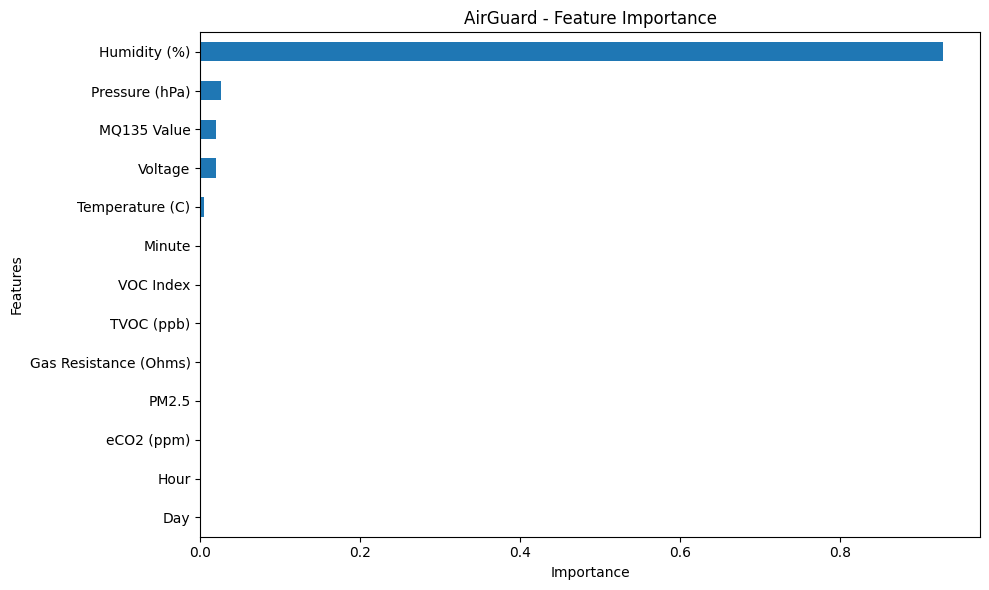

In [16]:
# Get the trained Random Forest model
rf_model = models["Random Forest"]

# Calculate feature importance
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# Display feature importance
print("Feature Importance:")
print(feature_importance)

# Plot feature importance
plt.figure(figsize=(10, 6))
feature_importance.sort_values().plot(kind='barh')

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("AirGuard - Feature Importance")
plt.tight_layout()
plt.show()

In [17]:
import joblib

# Save the trained Random Forest model
joblib.dump(rf_model, "airguard_random_forest.pkl")

print("AirGuard model saved successfully!")

AirGuard model saved successfully!


In [18]:
import os

print(os.path.exists("airguard_random_forest.pkl"))

True


In [19]:
# Check the exact feature order for the Streamlit app

print("AirGuard input features:")
for i, feature in enumerate(X.columns, start=1):
    print(f"{i}. {feature}")

AirGuard input features:
1. Temperature (C)
2. Humidity (%)
3. Pressure (hPa)
4. Gas Resistance (Ohms)
5. PM2.5
6. TVOC (ppb)
7. eCO2 (ppm)
8. VOC Index
9. MQ135 Value
10. Voltage
11. Hour
12. Minute
13. Day


In [20]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

# Load trained model
model = joblib.load("airguard_random_forest.pkl")

# Page configuration
st.set_page_config(
    page_title="AirGuard - Indoor Air Quality Predictor",
    page_icon="🌬️",
    layout="centered"
)

# Title
st.title("🌬️ AirGuard")
st.subheader("Indoor Air Quality PPM Predictor")

st.write(
    "Enter indoor environmental and sensor measurements "
    "to estimate the air-quality PPM level using machine learning."
)

st.info(
    "⚠️ This prediction is for educational and decision-support purposes "
    "only. It does not replace professional air-quality testing."
)

# User inputs
st.header("Enter Sensor Readings")

temperature = st.number_input(
    "Temperature (°C)",
    min_value=-20.0,
    max_value=60.0,
    value=25.0
)

humidity = st.number_input(
    "Humidity (%)",
    min_value=0.0,
    max_value=100.0,
    value=50.0
)

pressure = st.number_input(
    "Pressure (hPa)",
    min_value=800.0,
    max_value=1100.0,
    value=1013.0
)

gas_resistance = st.number_input(
    "Gas Resistance (Ohms)",
    min_value=0,
    value=50000
)

pm25 = st.number_input(
    "PM2.5",
    min_value=0,
    value=10
)

tvoc = st.number_input(
    "TVOC (ppb)",
    min_value=0,
    value=10
)

eco2 = st.number_input(
    "eCO2 (ppm)",
    min_value=0,
    value=400
)

voc_index = st.number_input(
    "VOC Index",
    min_value=0,
    value=100
)

mq135 = st.number_input(
    "MQ135 Value",
    min_value=0,
    value=70
)

voltage = st.number_input(
    "Voltage",
    min_value=0.0,
    value=0.23,
    format="%.6f"
)

hour = st.slider(
    "Hour",
    min_value=0,
    max_value=23,
    value=12
)

minute = st.slider(
    "Minute",
    min_value=0,
    max_value=59,
    value=30
)

day = st.slider(
    "Day",
    min_value=1,
    max_value=31,
    value=15
)

# Prediction
if st.button("🔍 Predict PPM"):

    input_data = pd.DataFrame([[
        temperature,
        humidity,
        pressure,
        gas_resistance,
        pm25,
        tvoc,
        eco2,
        voc_index,
        mq135,
        voltage,
        hour,
        minute,
        day
    ]], columns=[
        "Temperature (C)",
        "Humidity (%)",
        "Pressure (hPa)",
        "Gas Resistance (Ohms)",
        "PM2.5",
        "TVOC (ppb)",
        "eCO2 (ppm)",
        "VOC Index",
        "MQ135 Value",
        "Voltage",
        "Hour",
        "Minute",
        "Day"
    ])

    prediction = model.predict(input_data)[0]

    st.success(f"🌬️ Predicted PPM: {prediction:.4f}")

    st.write(
        "The predicted value is an estimate generated by the "
        "AirGuard machine-learning model."
    )

Writing app.py


In [21]:
import os

print(os.path.exists("app.py"))

True


In [22]:
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 80.4 MB/s eta 0:00:00


In [23]:
!streamlit run app.py &>/content/streamlit.log &

In [24]:
!cat /content/streamlit.log



2026-08-14 15:35:21.788 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://136.115.22.50:8501



In [25]:
import joblib
import pandas as pd

# Load the saved AirGuard model
model = joblib.load("airguard_random_forest.pkl")

# Sample indoor air-quality readings
sample_data = pd.DataFrame([[
    27.5,      # Temperature (C)
    41.6,      # Humidity (%)
    889.1,     # Pressure (hPa)
    52053,     # Gas Resistance (Ohms)
    7,         # PM2.5
    5,         # TVOC (ppb)
    400,       # eCO2 (ppm)
    93,        # VOC Index
    73,        # MQ135 Value
    0.235484,  # Voltage
    12,        # Hour
    56,        # Minute
    9          # Day
]], columns=[
    "Temperature (C)",
    "Humidity (%)",
    "Pressure (hPa)",
    "Gas Resistance (Ohms)",
    "PM2.5",
    "TVOC (ppb)",
    "eCO2 (ppm)",
    "VOC Index",
    "MQ135 Value",
    "Voltage",
    "Hour",
    "Minute",
    "Day"
])

prediction = model.predict(sample_data)[0]

print(f"AirGuard Test Prediction: {prediction:.4f} PPM")

AirGuard Test Prediction: 0.4750 PPM


In [26]:
%%writefile requirements.txt

streamlit
pandas
scikit-learn
joblib
openpyxl

Writing requirements.txt


In [27]:
print(open("requirements.txt").read())


streamlit
pandas
scikit-learn
joblib
openpyxl



In [28]:
%%writefile README.md

# 🌬️ AirGuard — Indoor Air Quality PPM Predictor

## 📌 Project Overview

AirGuard is a machine learning-based web application that predicts indoor air-quality PPM levels from environmental and sensor measurements.

The project transforms raw indoor air-quality sensor data into an interactive prediction tool using machine learning and Streamlit.

## 🎯 Problem Statement

Indoor air quality can be affected by environmental conditions and different air-quality indicators. Monitoring these conditions can help identify changes in indoor air quality.

The objective of AirGuard is to use machine learning to estimate PPM levels from measurable indoor environmental and sensor readings.

> **Disclaimer:** AirGuard provides an ML-based estimate for educational and decision-support purposes. It does not replace professional air-quality monitoring or laboratory testing.

## 📊 Dataset

The project uses the IoT-Enabled Indoor Air Quality Monitoring Dataset.

The dataset contains:

- 1,500 observations
- 12 original variables
- Temperature
- Humidity
- Atmospheric pressure
- Gas resistance
- PM2.5
- TVOC
- eCO2
- VOC Index
- MQ135 Value
- Voltage
- PPM
- Timestamp

## 🔧 Data Preparation

The following preprocessing steps were performed:

- Converted Timestamp into datetime format
- Extracted Hour, Minute, and Day features
- Removed the original Timestamp column
- Checked missing values
- Checked duplicate records
- Separated input features and target variable
- Split the data into training and testing sets

## 🤖 Machine Learning Models

Three regression models were trained and compared:

1. Linear Regression
2. Random Forest Regressor
3. Gradient Boosting Regressor

### Model Results

| Model | MAE | RMSE | R² Score |
|---|---:|---:|---:|
| Linear Regression | 0.0088 | 0.0111 | 0.9613 |
| Random Forest | 0.0006 | 0.0012 | **0.9996** |
| Gradient Boosting | 0.0010 | 0.0015 | 0.9993 |

### 🏆 Best Model

The **Random Forest Regressor** achieved the best overall performance:

- MAE: **0.0006**
- RMSE: **0.0012**
- R² Score: **0.9996**

Therefore, Random Forest was selected as the final AirGuard model.

## 📊 Feature Importance

The Random Forest model identified **Humidity (%)** as the strongest predictive feature in this dataset, followed by Pressure, MQ135 Value, and Voltage.

## 🌐 Streamlit Application

AirGuard provides an interactive interface where users can enter indoor environmental and sensor measurements and receive a predicted PPM value.

### Main Inputs

- Temperature
- Humidity
- Pressure
- Gas Resistance
- PM2.5
- TVOC
- eCO2
- VOC Index
- MQ135 Value
- Voltage
- Hour
- Minute
- Day

### Live Application

**Live App:** Coming soon

## 📁 Project Structure

```text
AirGuard/
│
├── app.py
├── airguard_random_forest.pkl
├── requirements.txt
├── README.md
└── Task_11_AirGuard_Indoor_Air_Quality_Prediction.ipynb

Writing README.md


In [30]:
%%writefile README.md

Overwriting README.md


In [31]:
import os

files = [
    "app.py",
    "airguard_random_forest.pkl",
    "requirements.txt"
]

for file in files:
    print(file, ":", os.path.exists(file))

app.py : True
airguard_random_forest.pkl : True
requirements.txt : True
